In [1]:
import numpy as np 
import pandas as pd 
import datetime
import re
import os, os.path
import time
from sklearn.model_selection import train_test_split
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

from pprint import pprint
import json

2024-06-06 18:27:29.751554: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [36]:
training_data_path = './out_12May2024/training/'
testing_data_path = './out_12May2024/testing/'
BUFFER_SIZE = 130
OVERLAP = 30

In [3]:
def get_class_ids(directory):
    # Get a list of all CSV files in the directory
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]

    # Extract unique class names from file names
    class_names = set(f.split('.')[0] for f in csv_files)

    # Create a dictionary mapping class names to new IDs
    class_to_id = {class_name: i for i, class_name in enumerate(sorted(class_names))}

    return class_to_id

In [4]:
class_ids_map = get_class_ids(training_data_path)
class_names = list(class_ids_map.keys())
print(class_ids_map)
print(len(class_ids_map))


{'curl': 0, 'dumbell_row': 1, 'front_raise': 2, 'hammer_curl': 3, 'non_exersice': 4, 'shoulder_press': 5}
6


In [9]:
def build_dataset_df(directory, gest_id):
    # Get CSV files from dirctory
    files = os.listdir(directory)

    # Empty DF for dataset
    completedf = pd.DataFrame(columns=['gesture', 'acceleration'])

    for file in files:
        # Check if the file matches the CSV format
        if file.endswith('.csv'):
            # Determine the class of the file by its name
            for gesture in gest_id.keys():
                if file.startswith(gesture):
                    df_temp = pd.read_csv(os.path.join(directory, file))
                    # Data transformation
                    x = df_temp[['ax', 'ay', 'az', 'q0', 'q1', 'q2', 'q3']].to_numpy()
                    series = pd.Series(data={'gesture': gesture, 'acceleration': x.tolist()})
                    df_temp2 = pd.DataFrame([series])
                    completedf = pd.concat([completedf, df_temp2], ignore_index=True)
                    break

    # Applying the dictionary to convert text labels to numerical
    completedf['gesture'] = completedf['gesture'].apply(lambda x: gest_id[x])

    return completedf


In [14]:
def split_sequences(dataframe, sequence_length, overlap):
    #Split the dataframe into sequences of a given length, including all relevant columns.
    X = []
    step = sequence_length - overlap
    for i in range(0, len(dataframe) - sequence_length + 1, step):
        sequence = dataframe[i:i+sequence_length]
        X.append(sequence)
    return np.array(X)


In [29]:
def info_dataset(pd):
    lensum=0
    for gest in pd:
        lensum+=len(gest)  
    print("Mean number of points in sample: ", lensum/len(pd))
    print("Number of samples : ", len(pd))
    print("Number of measurement points : ", lensum)    
    

def split_dataset(df, window_size=BUFFER_SIZE, overlap=OVERLAP):
    # Empty DataFrame for splitted dataset
    pad_train_df = pd.DataFrame(columns=['gesture','acceleration'])

    proc_acc = df['acceleration'].to_numpy()

    print("Window Size : ", window_size)
    print("Overlap Size : ", overlap)
    print("\nBefore split --------------------------------")
    info_dataset(proc_acc)

    for idx4, proacc in enumerate(proc_acc):
        pad_acc = split_sequences(proacc, window_size, overlap)
        for half in pad_acc:
            padSeries = pd.Series(data={'gesture': df['gesture'][idx4],
                                          'acceleration': half.tolist()})
            paddf_temp=pd.DataFrame([padSeries])
            pad_train_df=pd.concat([pad_train_df,paddf_temp], ignore_index=True)

    print("After split --------------------------------")
    info_dataset(pad_train_df['acceleration'].to_numpy())
    
    return pad_train_df


In [58]:
datasetdf = build_dataset_df(training_data_path, class_ids_map)

# Saving the complete dataset DataFrame to CSV
datasetdf.to_csv('complete_data.csv', index=False)

train_ratio = 0.8

train_set, val_set = train_test_split(datasetdf, test_size=1 - train_ratio, random_state=0)

# Default dataset
train_set.to_csv('train_set.csv', index=False)
val_set.to_csv('val_set.csv', index=False)

# Splitting dataset into window & overlap
train_set = pd.read_csv('train_set.csv',converters={'acceleration': eval})
val_set = pd.read_csv('val_set.csv',converters={'acceleration': eval})

print("\nTrain dataset\n")
splited_train_dataset = split_dataset(train_set, BUFFER_SIZE, overlap=OVERLAP)
print("\nVal dataset\n")
splited_val_dataset = split_dataset(val_set, BUFFER_SIZE, overlap=OVERLAP)

splited_train_dataset.to_csv('train_set_' + str(BUFFER_SIZE) + '.csv', index=False)
splited_val_dataset.to_csv('val_set_' + str(BUFFER_SIZE) + '.csv', index=False)
print("Done")


Train dataset

Window Size :  130
Overlap Size :  30

Before split --------------------------------
Mean number of points in sample:  500.0
Number of samples :  672
Number of measurement points :  336000
After split --------------------------------
Mean number of points in sample:  130.0
Number of samples :  2688
Number of measurement points :  349440

Val dataset

Window Size :  130
Overlap Size :  30

Before split --------------------------------
Mean number of points in sample:  500.0
Number of samples :  168
Number of measurement points :  84000
After split --------------------------------
Mean number of points in sample:  130.0
Number of samples :  672
Number of measurement points :  87360
Done


In [59]:
test_datasetdf = build_dataset_df(testing_data_path, class_ids_map)

# Saving the complete dataset DataFrame to CSV
test_datasetdf.to_csv('test_data.csv', index=False)

# Splitted window size
test_set = pd.read_csv('test_data.csv',converters={'acceleration': eval})

print("\nTest dataset\n")
splited_test_dataset = split_dataset(test_set, BUFFER_SIZE, overlap=OVERLAP)

splited_test_dataset.to_csv('test_set_' + str(BUFFER_SIZE) + '.csv', index=False)
print("Done")



Test dataset

Window Size :  130
Overlap Size :  30

Before split --------------------------------
Mean number of points in sample:  500.0
Number of samples :  210
Number of measurement points :  105000
After split --------------------------------
Mean number of points in sample:  130.0
Number of samples :  840
Number of measurement points :  109200
Done


## Train model

In [84]:
def reshape_function(data, label):
    reshaped_data = tf.reshape(data, [-1, 7, 1])
    return reshaped_data, label


In [85]:
train_set = pd.read_csv('train_set_' + str(BUFFER_SIZE) + '.csv',converters={'acceleration': eval})
test_set = pd.read_csv('test_set_' + str(BUFFER_SIZE) + '.csv',converters={'acceleration': eval})
val_set = pd.read_csv('val_set_' + str(BUFFER_SIZE) + '.csv',converters={'acceleration': eval})


In [86]:
samples = len(train_set['acceleration'][0])
print(samples)


130


In [87]:
tensor_train_set = tf.data.Dataset.from_tensor_slices(
    (np.array(train_set['acceleration'].tolist(),dtype=np.float64),
     train_set['gesture'].tolist()))

tensor_test_set = tf.data.Dataset.from_tensor_slices(
    (np.array(test_set['acceleration'].tolist(),dtype=np.float64),
     test_set['gesture'].tolist()))

tensor_val_set = tf.data.Dataset.from_tensor_slices(
    (np.array(val_set['acceleration'].tolist(),dtype=np.float64),
     val_set['gesture'].tolist()))


In [88]:
tensor_train_set_cnn = tensor_train_set.map(reshape_function)
tensor_test_set_cnn = tensor_test_set.map(reshape_function)
tensor_val_set_cnn = tensor_val_set.map(reshape_function)


In [89]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(8, (4, 3),padding="same",activation="relu",
                           input_shape=(samples, 7, 1)),  # output_shape=(batch, 760, 3, 8)
    tf.keras.layers.MaxPool2D((6, 3)),  # (batch, 126, 1, 8)
    tf.keras.layers.Dropout(0.1),  # (batch, 126, 1, 8)
    tf.keras.layers.Conv2D(16, (4, 1), padding="same",activation="relu"), # (batch, 126, 1, 16)
    tf.keras.layers.MaxPool2D((6, 1), padding="same"),  # (batch, 21, 1, 16)
    tf.keras.layers.Dropout(0.1),  # (batch, 21, 1, 16)
    tf.keras.layers.Flatten(),  # (batch, 336)
    tf.keras.layers.Dense(16, activation="relu"),  # (batch, 16)
    tf.keras.layers.Dropout(0.1),  # (batch, 16)
    tf.keras.layers.Dense(len(class_ids_map), activation="softmax")  # (batch, 4)
])


In [90]:
#calculate_model_size(lstm_model)
epochs_cnn = 60
batch_size = 8


#calculate_model_size(cnn_model3)
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])



In [91]:
tensor_train_set_cnn = tensor_train_set_cnn.batch(batch_size).repeat()
tensor_test_set_cnn = tensor_test_set_cnn.batch(batch_size)
tensor_val_set_cnn = tensor_val_set_cnn.batch(batch_size)


In [92]:
history = cnn_model.fit(
    tensor_train_set_cnn,
    epochs=epochs_cnn,
    validation_data=tensor_val_set_cnn,
    steps_per_epoch=300,
    ) #validation_steps=int((len(val_set) - 1) / batch_size2 + 1)



Epoch 1/60
300/300 [==============================] - 3s 8ms/step - loss: 1.2489 - accuracy: 0.5542 - val_loss: 0.8051 - val_accuracy: 0.7738
Epoch 2/60
300/300 [==============================] - 2s 7ms/step - loss: 0.7707 - accuracy: 0.7475 - val_loss: 0.5673 - val_accuracy: 0.8557
Epoch 3/60
300/300 [==============================] - 3s 9ms/step - loss: 0.6460 - accuracy: 0.8071 - val_loss: 0.4592 - val_accuracy: 0.8824
Epoch 4/60
300/300 [==============================] - 3s 10ms/step - loss: 0.5483 - accuracy: 0.8329 - val_loss: 0.4105 - val_accuracy: 0.9062
Epoch 5/60
300/300 [==============================] - 2s 7ms/step - loss: 0.4619 - accuracy: 0.8617 - val_loss: 0.3825 - val_accuracy: 0.9301
Epoch 6/60
300/300 [==============================] - 2s 8ms/step - loss: 0.4288 - accuracy: 0.8821 - val_loss: 0.3750 - val_accuracy: 0.9182
Epoch 7/60
300/300 [==============================] - 2s 7ms/step - loss: 0.4150 - accuracy: 0.8858 - val_loss: 0.3169 - val_accuracy: 0.9226
Epoch

300/300 [==============================] - 2s 7ms/step - loss: 0.1679 - accuracy: 0.9492 - val_loss: 0.2837 - val_accuracy: 0.9464
Epoch 59/60
300/300 [==============================] - 2s 7ms/step - loss: 0.1953 - accuracy: 0.9413 - val_loss: 0.2564 - val_accuracy: 0.9405
Epoch 60/60
300/300 [==============================] - 2s 7ms/step - loss: 0.1899 - accuracy: 0.9392 - val_loss: 0.2631 - val_accuracy: 0.9464


In [93]:
loss_cnn, acc_cnn = cnn_model.evaluate(tensor_val_set_cnn)
pred_cnn = np.argmax(cnn_model.predict(tensor_val_set_cnn), axis=1)

id_to_gest = {v: k for k, v in class_ids_map.items()}
y_pred_label = [id_to_gest[i] for i in pred_cnn]

confusion_cnn = tf.math.confusion_matrix(
    labels=tf.constant(val_set['gesture'].to_numpy()),
    predictions=tf.constant(pred_cnn),
    num_classes=len(class_ids_map))

print(confusion_cnn)
print("Loss {}, Accuracy {}".format(loss_cnn, acc_cnn))

84/84 [==============================] - 0s 3ms/step
tf.Tensor(
[[ 83   0   0   0  13   0]
 [  0  33   0   0   3   0]
 [  0   0  80   0   3   1]
 [  0   0   0  56   4   0]
 [  1   4   1   0 326   0]
 [  0   0   0   0   6  58]], shape=(6, 6), dtype=int32)
Loss 0.26314231753349304, Accuracy 0.9464285969734192



Classification Report:
                 precision    recall  f1-score   support

          curl       0.99      0.86      0.92        96
   dumbell_row       0.89      0.92      0.90        36
   front_raise       0.99      0.95      0.97        84
   hammer_curl       1.00      0.93      0.97        60
  non_exersice       0.92      0.98      0.95       332
shoulder_press       0.98      0.91      0.94        64

      accuracy                           0.95       672
     macro avg       0.96      0.93      0.94       672
  weighted avg       0.95      0.95      0.95       672



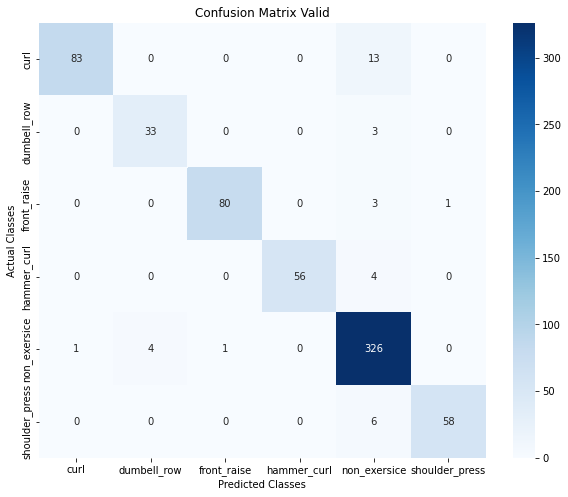

In [94]:
confusion_cnn_np = confusion_cnn.numpy()
true_labels = val_set['gesture'].to_numpy()
true_labels = [id_to_gest[i] for i in true_labels]
print('\nClassification Report:\n', classification_report(true_labels, y_pred_label))

# Visualize Confussion Matrix
plt.figure(figsize=(10, 8))
sb.heatmap(confusion_cnn_np, annot=True, fmt="d", cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix Valid')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()

In [95]:
loss_cnn, acc_cnn = cnn_model.evaluate(tensor_test_set_cnn)
pred_cnn = np.argmax(cnn_model.predict(tensor_test_set_cnn), axis=1)

id_to_gest = {v: k for k, v in class_ids_map.items()}
y_pred_label = [id_to_gest[i] for i in pred_cnn]

confusion_cnn = tf.math.confusion_matrix(
    labels=tf.constant(test_set['gesture'].to_numpy()),
    predictions=tf.constant(pred_cnn),
    num_classes=len(class_ids_map))

print(confusion_cnn)
print("Loss {}, Accuracy {}".format(loss_cnn, acc_cnn))

105/105 [==============================] - 0s 3ms/step
tf.Tensor(
[[ 51   0   0   0  13   0]
 [  0  62   0   0   2   0]
 [  0   0 117   0   3   0]
 [  0   0   0  76   0   0]
 [  5   5   0   1 404   1]
 [  0   0   0   0  10  90]], shape=(6, 6), dtype=int32)
Loss 0.22307470440864563, Accuracy 0.9523809552192688



Classification Report:
                 precision    recall  f1-score   support

          curl       0.91      0.80      0.85        64
   dumbell_row       0.93      0.97      0.95        64
   front_raise       1.00      0.97      0.99       120
   hammer_curl       0.99      1.00      0.99        76
  non_exersice       0.94      0.97      0.95       416
shoulder_press       0.99      0.90      0.94       100

      accuracy                           0.95       840
     macro avg       0.96      0.94      0.95       840
  weighted avg       0.95      0.95      0.95       840



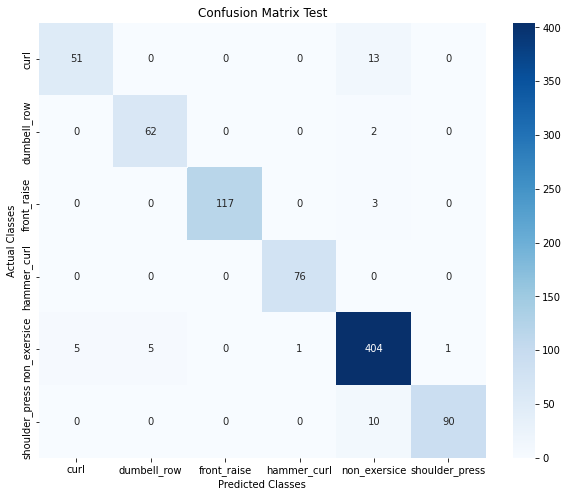

In [96]:
confusion_cnn_np = confusion_cnn.numpy()
true_labels = test_set['gesture'].to_numpy()
true_labels = [id_to_gest[i] for i in true_labels]
print('\nClassification Report:\n', classification_report(true_labels, y_pred_label))

# Visualize Confussion Matrix
plt.figure(figsize=(10, 8))
sb.heatmap(confusion_cnn_np, annot=True, fmt="d", cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix Test')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()

## Save and Export Models

In [97]:
MODEL_NAME = 'test_overlap'
DATE = "06.06.2024"
TFLITE_MODEL = MODEL_NAME + str(BUFFER_SIZE) + '_' + DATE + ".tflite"
MODEL_NAME =  MODEL_NAME + '_' + str(BUFFER_SIZE) + '_' + DATE
KERAS_MODEL = MODEL_NAME + ".h5"
TFLITE_MODEL = MODEL_NAME + ".tflite"


In [98]:
cnn_model.save(KERAS_MODEL) 


In [99]:
converter = tf.lite.TFLiteConverter.from_keras_model(cnn_model)
cnn_tflite_model = converter.convert()

open(TFLITE_MODEL, "wb").write(cnn_tflite_model)


INFO:tensorflow:Assets written to: /var/folders/c5/xpfx3gxx5d34j23111nbtn000000gn/T/tmpp5bmd06x/assets


INFO:tensorflow:Assets written to: /var/folders/c5/xpfx3gxx5d34j23111nbtn000000gn/T/tmpp5bmd06x/assets
2024-06-06 20:11:04.316444: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:362] Ignored output_format.
2024-06-06 20:11:04.316469: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:365] Ignored drop_control_dependency.


14680

## Export config

In [100]:
'''
Current config for inference
{
    "model_path": "../models/test.tflite",
    "means": [0.3981, 0.4978, 0.2766, 0.6055, 0.2624, -0.0003, 0.2684],
    "std_devs": [0.8194, 0.557, 0.5193, 0.2391, 0.3964, 0.3843, 0.3613],
    "buffer_size": 910,
    "class_names": ["curl", "front_raise", "shoulder_press", "non_exersice", "hammer_curl"],
    "comments": "CNN plus hammer_curl clas"
}
'''

# Load the JSON file into a Python dictionary
with open('test.json') as f:
    config = json.load(f)

pprint(config)
print('-------------')
config["class_names"] = list(class_ids_map.keys())
config["buffer_size"] = BUFFER_SIZE * 7
config["comments"] = "Overlap"
config["model_path"] = '../models/' + TFLITE_MODEL

pprint(config)

# Save the updated dictionary back to the JSON file
with open('test_overlap.json', 'w+') as f:
    json.dump(config, f)

{'buffer_size': 910,
 'class_names': ['curl',
                 'dumbell_row',
                 'front_raise',
                 'hammer_curl',
                 'non_exersice',
                 'shoulder_press'],
 'comments': 'Training pipeline automatization',
 'means': [0.4401, 0.5026, 0.225, 0.5947, 0.2694, -0.0407, 0.2378],
 'model_path': '../models/test_130_13.05.2024.tflite',
 'std_devs': [0.8218, 0.5361, 0.5233, 0.2392, 0.3975, 0.4034, 0.371]}
-------------
{'buffer_size': 910,
 'class_names': ['curl',
                 'dumbell_row',
                 'front_raise',
                 'hammer_curl',
                 'non_exersice',
                 'shoulder_press'],
 'comments': 'Overlap',
 'means': [0.4401, 0.5026, 0.225, 0.5947, 0.2694, -0.0407, 0.2378],
 'model_path': '../models/test_overlap_130_06.06.2024.tflite',
 'std_devs': [0.8218, 0.5361, 0.5233, 0.2392, 0.3975, 0.4034, 0.371]}
